In [1]:
import glob
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
mpl.rcParams.update({
    "font.family":        "serif",
    "font.size":          10,
    "text.color":         "black",
    "axes.titlesize":     11,
    "axes.labelsize":     10,
    "axes.labelcolor":    "black",
    "axes.edgecolor":     "black",
    "xtick.labelsize":    9,
    "xtick.color":        "black",
    "ytick.labelsize":    9,
    "ytick.color":        "black",
    "legend.fontsize":    9,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.color":         "black",
    "grid.linestyle":     "--",
    "grid.linewidth":     0.5,
    "grid.alpha":         0.2,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.facecolor":  "white",
})

In [3]:
POWER_CSV = None

if POWER_CSV is None:
    candidates = glob.glob('power_*.csv')
    if not candidates:
        raise FileNotFoundError('power_*.csv 파일을 찾을 수 없습니다. POWER_CSV를 직접 지정하세요.')
    POWER_CSV = max(candidates, key=os.path.getmtime)

df = pd.read_csv(POWER_CSV)
print(f'loaded: {POWER_CSV}  rows={len(df)}')

loaded: power_20260527_140323.csv  rows=76


In [4]:
if 'all_mw' in df.columns:
    power_col = 'all_mw'
elif 'board_5v0_mw' in df.columns:
    power_col = 'board_5v0_mw'
elif 'sys_5v0_mw' in df.columns:
    power_col = 'sys_5v0_mw'
else:
    raise KeyError('all_mw, board_5v0_mw 또는 sys_5v0_mw 컬럼이 필요합니다.')

df = df.dropna(subset=['elapsed_s', power_col]).copy()
df['power_w'] = df[power_col] / 1000.0

p = df['power_w']
print(f"n={len(p):4d}  mean={p.mean():.3f} W  std={p.std():.3f} W  "
      f"min={p.min():.3f} W  max={p.max():.3f} W")

n=  76  mean=50.067 W  std=13.661 W  min=14.370 W  max=57.436 W


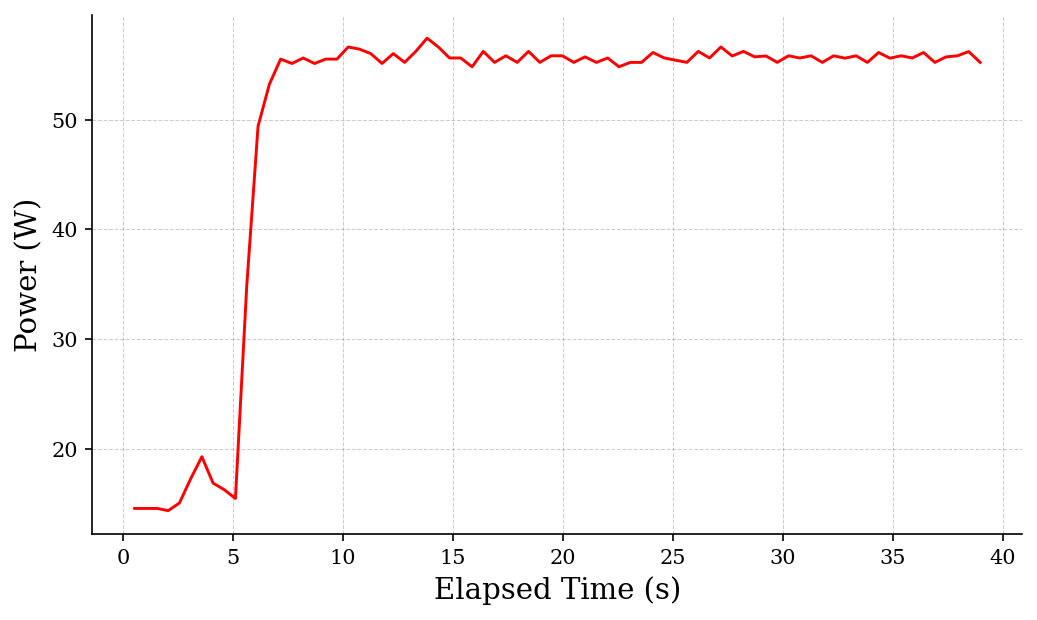

In [5]:
AXIS_FONT_SIZE = 14
TICK_FONT_SIZE = 10

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(data=df, x='elapsed_s', y='power_w', color='red', linewidth=1.4, ax=ax)
ax.set_xlabel('Elapsed Time (s)', fontsize=AXIS_FONT_SIZE)
ax.set_ylabel('Power (W)', fontsize=AXIS_FONT_SIZE)
ax.tick_params(axis='both', labelsize=TICK_FONT_SIZE)

(10.0, 60.0)

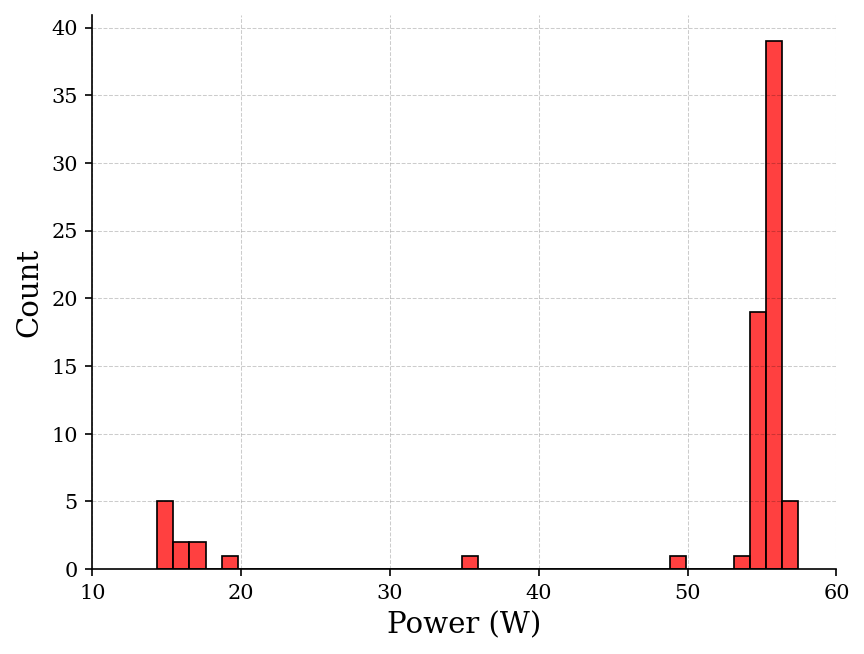

In [8]:
AXIS_FONT_SIZE = 14
TICK_FONT_SIZE = 10

fig, ax = plt.subplots(figsize=(6.4, 4.8))
sns.histplot(df['power_w'], bins=40, color='red', edgecolor='black', ax=ax)
ax.set_xlabel('Power (W)', fontsize=AXIS_FONT_SIZE)
ax.set_ylabel('Count', fontsize=AXIS_FONT_SIZE)
ax.tick_params(axis='both', labelsize=TICK_FONT_SIZE)
ax.set_xlim(10, 60)